# 经济订货批量（EOQ）分析 — A类产品

**业务场景：** 基于ABC分析结果，对A类高价值产品应用EOQ模型，计算最优订货批量，平衡订货成本与持有成本。

**EOQ公式：** $EOQ = \sqrt{\frac{2DS}{H}}$

其中：
- D = 年需求量
- S = 每次订货成本
- H = 单位年持有成本（= 单位成本 × 持有成本率）


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Heiti SC', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')


In [2]:
# Load product data
df = pd.read_csv('../data/superstore_products.csv')
df['Annual_Volume'] = df['Annual_Demand'] * df['Unit_Cost']
df = df.sort_values('Annual_Volume', ascending=False).reset_index(drop=True)

# ABC classification
total_volume = df['Annual_Volume'].sum()
df['Cumulative_Pct'] = (df['Annual_Volume'].cumsum() / total_volume * 100).round(2)

def classify(cum):
    if cum <= 80: return 'A'
    elif cum <= 95: return 'B'
    else: return 'C'

df['ABC_Class'] = df['Cumulative_Pct'].apply(classify)

# Filter A-class items
class_a = df[df['ABC_Class'] == 'A'].copy()
print(f'A类产品数量: {len(class_a)}')
print(f'A类总消耗金额: ${class_a.Annual_Volume.sum():,.2f}')
print(f'A类平均单价: ${class_a.Unit_Cost.mean():,.2f}')


A类产品数量: 125
A类总消耗金额: $1,104,540.29
A类平均单价: $426.89


In [3]:
# EOQ Parameters
ORDERING_COST = 50      # $/order (fixed cost per order: admin, shipping setup)
HOLDING_RATE = 0.25     # 25% annual holding cost rate

def calculate_eoq(demand, unit_cost, ordering_cost=ORDERING_COST, holding_rate=HOLDING_RATE):
    """Calculate Economic Order Quantity."""
    holding_cost = unit_cost * holding_rate
    if holding_cost <= 0:
        return 0, 0, 0, 0
    eoq = np.sqrt((2 * demand * ordering_cost) / holding_cost)
    annual_orders = demand / eoq
    annual_ordering_cost = annual_orders * ordering_cost
    annual_holding_cost = (eoq / 2) * holding_cost
    total_cost = annual_ordering_cost + annual_holding_cost
    return eoq, annual_orders, total_cost, holding_cost

# Calculate EOQ for each A-class product
results = []
for _, row in class_a.iterrows():
    eoq, n_orders, total_cost, holding_cost_per_unit = calculate_eoq(
        row['Annual_Demand'], row['Unit_Cost'])
    results.append({
        'Product_ID': row['Product_ID'],
        'Product_Name': row['Product_Name'][:40],
        'Category': row['Category'],
        'Annual_Demand': row['Annual_Demand'],
        'Unit_Cost': row['Unit_Cost'],
        'Annual_Volume': row['Annual_Volume'],
        'EOQ': round(eoq, 0),
        'Orders_Per_Year': round(n_orders, 2),
        'Order_Interval_Days': round(365 / n_orders, 0) if n_orders > 0 else 0,
        'Annual_Ordering_Cost': round(annual_ordering_cost := n_orders * ORDERING_COST, 2),
        'Annual_Holding_Cost': round(eoq / 2 * holding_cost_per_unit, 2),
        'Total_Annual_Cost': round(total_cost, 2)
    })

eoq_df = pd.DataFrame(results)
eoq_df = eoq_df.sort_values('Annual_Volume', ascending=False).reset_index(drop=True)

print('📊 EOQ Analysis Results (Top 10 A-class Products):')
display(eoq_df.head(10).style.background_gradient(subset=['EOQ', 'Total_Annual_Cost'], cmap='Blues'))

print(f'\n📊 Summary:')
print(f'  Average EOQ: {eoq_df.EOQ.mean():.0f} units')
print(f'  Average orders/year: {eoq_df.Orders_Per_Year.mean():.1f}')
print(f'  Total annual cost (all A items): ${eoq_df.Total_Annual_Cost.sum():,.2f}')


📊 EOQ Analysis Results (Top 10 A-class Products):


,Product_ID,Product_Name,Category,Annual_Demand,Unit_Cost,Annual_Volume,EOQ,Orders_Per_Year,Order_Interval_Days,Annual_Ordering_Cost,Annual_Holding_Cost,Total_Annual_Cost
0,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,20,3079.991200,61599.824000,2.000000,12.410000,29.000000,620.480000,620.480000,1240.970000
1,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Co,Office Supplies,31,885.593032,27453.384000,4.000000,8.280000,44.000000,414.230000,414.230000,828.450000
2,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconf,Technology,6,3773.080000,22638.480000,1.000000,7.520000,49.000000,376.150000,376.150000,752.300000
3,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and,Furniture,39,560.784000,21870.576000,5.000000,7.390000,49.000000,369.720000,369.720000,739.440000
4,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding Syst,Office Supplies,37,535.769703,19823.479000,5.000000,7.040000,52.000000,351.990000,351.990000,703.980000
5,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Bindin,Office Supplies,48,396.343750,19024.500000,7.000000,6.900000,53.000000,344.820000,344.820000,689.650000
6,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,38,495.781211,18839.686000,6.000000,6.860000,53.000000,343.140000,343.140000,686.290000
7,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Pr,Technology,12,1531.241250,18374.895000,2.000000,6.780000,54.000000,338.890000,338.890000,677.770000
8,OFF-BI-10004995,GBC DocuBind P400 Electric Binding Syste,Office Supplies,27,665.372889,17965.068000,4.000000,6.700000,54.000000,335.080000,335.080000,670.170000
9,OFF-SU-10000151,High Speed Automatic Electric Letter Ope,Office Supplies,11,1548.210182,17030.312000,2.000000,6.530000,56.000000,326.250000,326.250000,652.500000



📊 Summary:
  Average EOQ: 6 units
  Average orders/year: 4.5
  Total annual cost (all A items): $56,613.06


## EOQ 敏感性分析

分析订货成本和持有成本率变化对EOQ的影响，验证模型的稳健性。


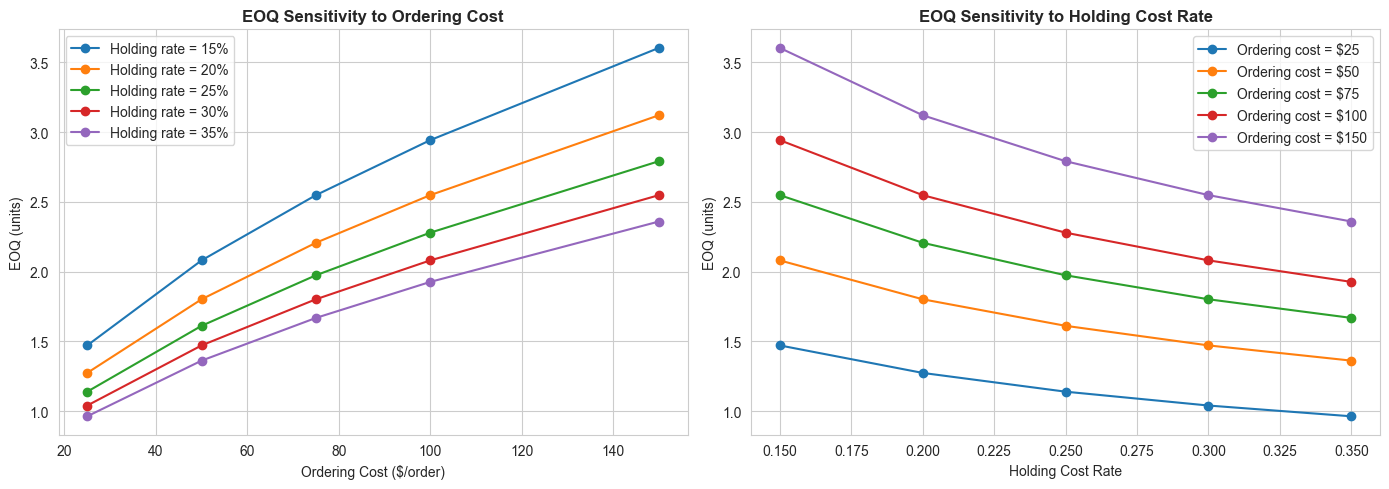

✅ EOQ sensitivity chart saved


In [4]:
# Sensitivity Analysis
# Take the top A product for demonstration
top_product = eoq_df.iloc[0]
demand = top_product['Annual_Demand']
unit_cost = top_product['Unit_Cost']

ordering_costs = [25, 50, 75, 100, 150]
holding_rates = [0.15, 0.20, 0.25, 0.30, 0.35]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sensitivity to ordering cost
ax = axes[0]
for hr in holding_rates:
    eoqs = [calculate_eoq(demand, unit_cost, oc, hr)[0] for oc in ordering_costs]
    ax.plot(ordering_costs, eoqs, 'o-', label=f'Holding rate = {hr:.0%}')
ax.set_xlabel('Ordering Cost ($/order)')
ax.set_ylabel('EOQ (units)')
ax.set_title('EOQ Sensitivity to Ordering Cost', fontweight='bold')
ax.legend()

# Sensitivity to holding rate
ax = axes[1]
for oc in ordering_costs:
    eoqs = [calculate_eoq(demand, unit_cost, oc, hr)[0] for hr in holding_rates]
    ax.plot(holding_rates, eoqs, 'o-', label=f'Ordering cost = ${oc}')
ax.set_xlabel('Holding Cost Rate')
ax.set_ylabel('EOQ (units)')
ax.set_title('EOQ Sensitivity to Holding Cost Rate', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../images/eoq_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EOQ sensitivity chart saved')


## 关键发现

1. **EOQ与单价负相关：** 高单价产品的EOQ更小，应高频小批量订购
2. **需求驱动：** 需求量大的产品即使单价高，EOQ也较大
3. **敏感性：** EOQ对持有成本率的变化比对订货成本更敏感
